In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as mcolors

from sklearn.linear_model import LinearRegression
from scipy.signal import savgol_filter
from sm import NeuralNet

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 12,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 10,    # affects horizontal colorbar ticks
    "ytick.labelsize": 10,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
})

cpu


In [3]:
state_dict = torch.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/models/sm_vMB_n_a=200.pth', weights_only=False, map_location='cpu')
args = state_dict['args']

model = NeuralNet(args['layer_dims'], args['x_mean'], args['x_std'], args['y_mean'], args['y_std'], batch_norm=False)
model.load_state_dict(state_dict['model_state_dict'])

model = model.to(device)

0.003003003003003003


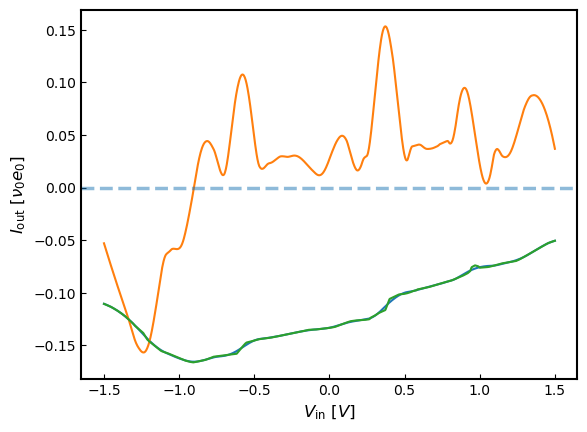

In [4]:
input_idx = 0
min_v = -1.5
max_v = 1.5
N = 1000

v_step = float((max_v - min_v) / (N - 1))
print(v_step)

c_volts = torch.from_numpy(np.random.uniform(min_v, max_v, 6)).expand(N, -1).type(torch.float32)
c_v_left, c_v_right = c_volts[:, :input_idx], c_volts[:, input_idx:]

input_range = torch.linspace(min_v, max_v, N).unsqueeze(1)
input_tensor = torch.cat([c_v_left, input_range, c_v_right], dim=1)
input_tensor = input_tensor.to(device)

model.eval()
with torch.no_grad():
    I_out = model(input_tensor).detach().cpu().numpy().squeeze()

wl = 101
po = 3
I_smooth = savgol_filter(x=I_out, window_length=wl, polyorder=po, delta=v_step, mode='interp')
I_deriv = savgol_filter(x=I_out, window_length=wl, polyorder=po, deriv=1, delta=v_step, mode='interp')

plotting_range = torch.linspace(min_v, max_v, N)

fig, ax = plt.subplots()
ax.plot(plotting_range, I_smooth)
ax.plot(plotting_range, I_deriv)
ax.plot(plotting_range, I_out)
ax.set_xlabel(r'$V_{\mathrm{in}}$ $[V]$')
ax.set_ylabel(r'$I_{\mathrm{out}}$ $[\nu_0 e_0]$')

ax.axhline(y=0.0, lw=2.5, ls='--', alpha=0.5)
ax.spines[:].set_linewidth(1.5)
ax.tick_params(direction='in')

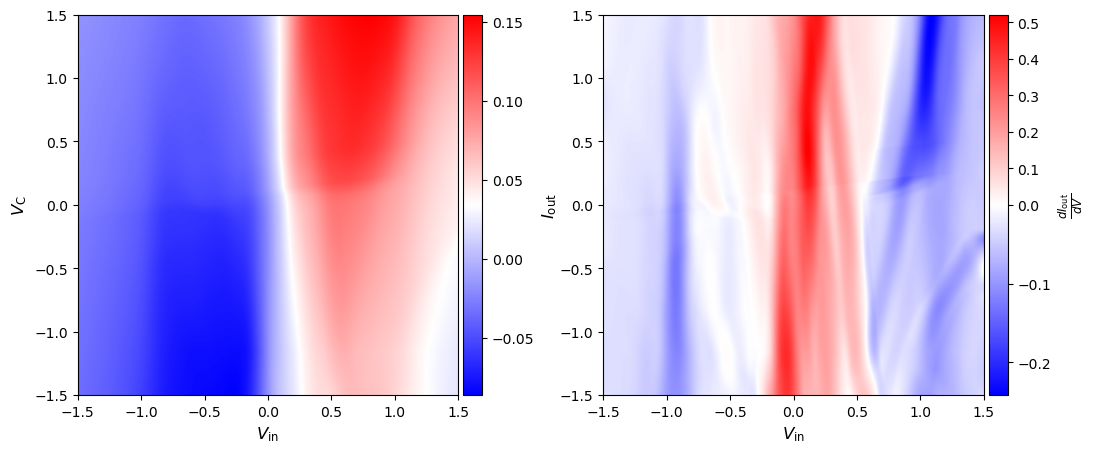

In [5]:
c_sweep_index = 2
input_idx = 0

in_features = 7

N = 1000
input_range = torch.linspace(min_v, max_v, N)
c_sweep_range = torch.linspace(min_v, max_v, N)
dx = float((max_v - min_v) / (N - 1))

other_controls = torch.tensor(np.random.uniform(min_v, max_v, 5)).type(torch.float32)

window_length = 101
poly_order = 3

I_lines = []
raw_output = []
model.eval()
other_control_cols = []
for k in range(in_features):
    if k not in (c_sweep_index, input_idx):
        other_control_cols.append(k)        

for c_v in c_sweep_range:
    input_tensor = torch.empty(N, 7, dtype=torch.float32)
    input_tensor[:, c_sweep_index] = c_v
    for l, other_c_v in zip(other_control_cols, other_controls):
        input_tensor[:, l] = other_c_v
    input_tensor[:, input_idx] = input_range
    input_tensor = input_tensor.to(device)
    with torch.no_grad():
        y_out = model(input_tensor).detach().cpu().squeeze().numpy()
    I_smooth = savgol_filter(x=y_out, window_length=window_length, polyorder=poly_order, delta=dx, mode='interp')
    I_lines.append(I_smooth)
    raw_output.append(y_out)
    
c_i_mat = np.stack(I_lines)

grad_list = []
for line in raw_output:
    #dIdV = np.gradient(line, dx)
    dIdV = savgol_filter(x=line, window_length=window_length, polyorder=poly_order, deriv=1, delta=dx, mode='interp')
    grad_list.append(dIdV)
grad = np.stack(grad_list)    

cmap = plt.get_cmap('bwr')
norm = mcolors.TwoSlopeNorm(vmin=grad.min(), vcenter=0.0, vmax=grad.max())
fig, ax = plt.subplots(ncols=2, figsize=(12, 6))
fig.subplots_adjust(wspace=.3)
extent = [input_range[0], input_range[-1], c_sweep_range[0], c_sweep_range[-1]]
im_0 = ax[0].imshow(c_i_mat, origin='lower', extent=extent, cmap=cmap)
im_1 = ax[1].imshow(grad, origin='lower', extent=extent, cmap=cmap, norm=norm)


divider_0 = make_axes_locatable(ax[0])
cax_0 = divider_0.append_axes('right', size='5%', pad=0.05)
cb_0 = fig.colorbar(im_0, cax=cax_0)
cb_0.set_label(label=r'$I_{\mathrm{out}}$')

divider_1 = make_axes_locatable(ax[1])
cax_1 = divider_1.append_axes('right', size='5%', pad=0.05)
cb_1 =fig.colorbar(im_1, cax=cax_1)
cb_1.set_label(label=r'$\frac{dI_{\mathrm{out}}}{dV}$')

ax[0].set_xlabel(r'$V_{\mathrm{in}}$')
ax[0].set_ylabel(r'$V_{\mathrm{C}}$')

ax[1].set_xlabel(r'$V_{\mathrm{in}}$')

for a in ax:
    pass

plt.show()